In [5]:
# P2PNet for Cell Detection - Imports and Setup
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils import data
import torchvision
from torchvision.models import vgg16_bn, resnet50
import numpy as np
import cv2
import os
import yaml
import random
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from scipy.optimize import linear_sum_assignment
import glob

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# 파라미터 로드
with open('utils/detail_args.yaml', errors='ignore') as f:
    params = yaml.safe_load(f)

# 6 클래스 cell type 정의
class_names = {
    0: "Epithelial",
    1: "Stromal", 
    2: "Lymphocyte",
    3: "Plasma",
    4: "Neutrophil",
    5: "Eosinophil",
}

num_classes = len(class_names)
print(f"Number of classes: {num_classes}")
print(f"Classes: {list(class_names.values())}")

Device: cuda:0
Number of classes: 6
Classes: ['Epithelial', 'Stromal', 'Lymphocyte', 'Plasma', 'Neutrophil', 'Eosinophil']


In [6]:
# P2PNet Model Architecture with Objectness Head
class P2PNet(nn.Module):
    """
    Point-to-Point Network for Cell Detection
    - Backbone: VGG16-BN or ResNet50
    - Head: Point regression + classification + objectness
    - Output: Direct point predictions (no anchors, no heatmaps)
    """
    def __init__(self, num_classes=6, backbone='vgg16_bn', row=2, line=2):
        super(P2PNet, self).__init__()
        self.num_classes = num_classes
        self.row = row
        self.line = line
        
        # Backbone
        if backbone == 'vgg16_bn':
            vgg = vgg16_bn(pretrained=True)
            self.features = nn.Sequential(*list(vgg.features.children())[:-1])
            in_channels = 512
        elif backbone == 'resnet50':
            resnet = resnet50(pretrained=True)
            self.features = nn.Sequential(
                resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool,
                resnet.layer1, resnet.layer2, resnet.layer3, resnet.layer4
            )
            in_channels = 2048
        else:
            raise ValueError(f"Unsupported backbone: {backbone}")
        
        # Regression head (point coordinates)
        self.reg_head = nn.Sequential(
            nn.Conv2d(in_channels, 256, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, row * line * 2, 1)
        )
        
        # Classification head
        self.cls_head = nn.Sequential(
            nn.Conv2d(in_channels, 256, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, row * line * num_classes, 1)
        )
        
        # Objectness head (foreground vs background)
        self.obj_head = nn.Sequential(
            nn.Conv2d(in_channels, 256, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, row * line * 1, 1)
        )
        
    def forward(self, x):
        batch_size = x.size(0)
        
        # Backbone
        features = self.features(x)
        
        # Regression
        pred_points = self.reg_head(features)
        pred_points = pred_points.permute(0, 2, 3, 1)
        
        # Classification
        pred_logits = self.cls_head(features)
        pred_logits = pred_logits.permute(0, 2, 3, 1)
        
        # Objectness
        pred_obj = self.obj_head(features)
        pred_obj = pred_obj.permute(0, 2, 3, 1)
        
        h_feat, w_feat = pred_points.shape[1], pred_points.shape[2]
        
        # Reshape
        pred_points = pred_points.reshape(batch_size, h_feat * w_feat * self.row * self.line, 2)
        pred_logits = pred_logits.reshape(batch_size, h_feat * w_feat * self.row * self.line, self.num_classes)
        pred_obj = pred_obj.reshape(batch_size, h_feat * w_feat * self.row * self.line)
        
        pred_points = torch.sigmoid(pred_points)
        
        return pred_points, pred_logits, pred_obj


# 모델 초기화
model = P2PNet(num_classes=num_classes, backbone='vgg16_bn', row=2, line=2).to(device)
print(f"\n✅ P2PNet model created")
print(f"  Backbone: VGG16-BN")
print(f"  Number of classes: {num_classes}")
print(f"  Grid: 2x2 per feature map cell")

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

/home/user/anaconda3/envs/urban/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/user/anaconda3/envs/urban/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



✅ P2PNet model created
  Backbone: VGG16-BN
  Number of classes: 6
  Grid: 2x2 per feature map cell
  Total parameters: 19,152,612
  Trainable parameters: 19,152,612


In [7]:
# P2PNet Loss Function with Hungarian Matching + Objectness
class P2PNetLoss(nn.Module):
    def __init__(self, num_classes=6, point_loss_coef=5.0, class_loss_coef=2.0, obj_loss_coef=2.0):
        super(P2PNetLoss, self).__init__()
        self.num_classes = num_classes
        self.point_loss_coef = point_loss_coef
        self.class_loss_coef = class_loss_coef
        self.obj_loss_coef = obj_loss_coef
        
    def focal_loss(self, logits, targets, alpha=0.25, gamma=2.0):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = alpha * (1 - pt) ** gamma * ce_loss
        return focal_loss.mean()
    
    def hungarian_matching(self, pred_points, pred_logits, pred_obj, gt_points, gt_classes):
        if len(gt_points) == 0:
            return torch.tensor([]).long(), torch.tensor([]).long()
        
        point_cost = torch.cdist(pred_points, gt_points, p=1) * 5.0
        pred_probs = F.softmax(pred_logits, dim=-1)
        class_cost = -pred_probs[:, gt_classes] * 2.0
        obj_probs = torch.sigmoid(pred_obj).unsqueeze(1)
        obj_cost = -(obj_probs.expand(-1, len(gt_points))) * 1.0
        
        cost_matrix = point_cost + class_cost + obj_cost
        cost_matrix_np = cost_matrix.detach().cpu().numpy()
        pred_idx, gt_idx = linear_sum_assignment(cost_matrix_np)
        
        return torch.from_numpy(pred_idx).long(), torch.from_numpy(gt_idx).long()
    
    def forward(self, pred_points, pred_logits, pred_obj, targets):
        batch_size = pred_points.size(0)
        device = pred_points.device
        
        total_point_loss = 0
        total_class_loss = 0
        total_obj_loss = 0
        num_matched = 0
        
        for b in range(batch_size):
            gt_points = targets['points'][b]
            gt_classes = targets['classes'][b].long()
            
            valid_mask = (gt_points[:, 0] >= 0) & (gt_points[:, 1] >= 0)
            gt_points = gt_points[valid_mask]
            gt_classes = gt_classes[valid_mask]
            
            if len(gt_points) == 0:
                obj_labels = torch.zeros(len(pred_obj[b]), device=device)
                obj_loss = F.binary_cross_entropy_with_logits(pred_obj[b], obj_labels)
                total_obj_loss += obj_loss
                continue
            
            pred_idx, gt_idx = self.hungarian_matching(
                pred_points[b], pred_logits[b], pred_obj[b], gt_points, gt_classes
            )
            
            if len(pred_idx) == 0:
                continue
            
            matched_pred_points = pred_points[b][pred_idx]
            matched_pred_logits = pred_logits[b][pred_idx]
            matched_pred_obj = pred_obj[b][pred_idx]
            matched_gt_points = gt_points[gt_idx]
            matched_gt_classes = gt_classes[gt_idx]
            
            point_loss = F.l1_loss(matched_pred_points, matched_gt_points, reduction='sum')
            class_loss = self.focal_loss(matched_pred_logits, matched_gt_classes)
            
            obj_labels_matched = torch.ones(len(pred_idx), device=device)
            obj_loss_matched = F.binary_cross_entropy_with_logits(matched_pred_obj, obj_labels_matched)
            
            unmatched_mask = torch.ones(len(pred_obj[b]), dtype=torch.bool, device=device)
            unmatched_mask[pred_idx] = False
            if unmatched_mask.sum() > 0:
                unmatched_pred_obj = pred_obj[b][unmatched_mask]
                obj_labels_unmatched = torch.zeros(len(unmatched_pred_obj), device=device)
                obj_loss_unmatched = F.binary_cross_entropy_with_logits(unmatched_pred_obj, obj_labels_unmatched)
                obj_loss = obj_loss_matched + obj_loss_unmatched * 0.1
            else:
                obj_loss = obj_loss_matched
            
            total_point_loss += point_loss
            total_class_loss += class_loss * len(pred_idx)
            total_obj_loss += obj_loss
            num_matched += len(pred_idx)
        
        if num_matched > 0:
            total_point_loss = total_point_loss / num_matched
            total_class_loss = total_class_loss / num_matched
        else:
            total_point_loss = torch.tensor(0.0, device=device)
            total_class_loss = torch.tensor(0.0, device=device)
        
        total_obj_loss = total_obj_loss / batch_size
        
        total_loss = (self.point_loss_coef * total_point_loss + 
                     self.class_loss_coef * total_class_loss + 
                     self.obj_loss_coef * total_obj_loss)
        
        loss_dict = {
            'total': total_loss.item(),
            'point': total_point_loss.item(),
            'class': total_class_loss.item(),
            'obj': total_obj_loss.item(),
            'num_matched': num_matched
        }
        
        return total_loss, loss_dict


# Loss function 초기화
criterion = P2PNetLoss(num_classes=num_classes, point_loss_coef=5.0, class_loss_coef=2.0, obj_loss_coef=2.0).to(device)
print(f"\n✅ P2PNet loss function created")
print(f"  Point loss coefficient: 5.0 (HIGH - 위치가 가장 중요)")
print(f"  Class loss coefficient: 2.0")
print(f"  Objectness loss coefficient: 2.0 (배경 거부)")
print(f"  Matching: Hungarian algorithm with objectness")


✅ P2PNet loss function created
  Point loss coefficient: 5.0 (HIGH - 위치가 가장 중요)
  Class loss coefficient: 2.0
  Objectness loss coefficient: 2.0 (배경 거부)
  Matching: Hungarian algorithm with objectness


In [8]:
# Data Loading
input_size = 512
label_dir = '../../data/spatialTranscriptome/detail_preprocessed_xenium/patch_train_data/**/annotation/'
label_files = sorted(glob.glob(f"{label_dir}/*.csv"))

image_filenames = []
labels = []

print("📂 Loading labels...")
for i in tqdm(range(len(label_files))):
    label_file = label_files[i]
    data_df = pd.read_csv(label_file)
    
    img_path = label_file.replace('/annotation', '/image').replace('.csv', '.png')
    
    if os.path.exists(img_path):
        image_filenames.append(img_path)
        
        arr = data_df.to_numpy()
        arr = arr[:, [4, 1, 0, 3, 2]]
        
        centers = []
        classes = []
        for row in arr:
            class_id = int(row[0])
            y_center_norm = row[1]
            x_center_norm = row[2]
            
            x_center_pixel = x_center_norm * input_size
            y_center_pixel = y_center_norm * input_size
            
            centers.append([x_center_pixel, y_center_pixel])
            classes.append(class_id)
        
        if len(centers) > 0:
            labels.append({
                'points': np.array(centers, dtype=np.float32),
                'classes': np.array(classes, dtype=np.int64)
            })
        else:
            image_filenames.pop()

print(f"✅ Loaded {len(image_filenames)} images with labels")

print("\n📷 Loading images...")
images = []
for i in tqdm(range(len(image_filenames))):
    image = cv2.imread(image_filenames[i])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    if image.shape[0] != 512 or image.shape[1] != 512:
        image = cv2.copyMakeBorder(
            image, 0, 512 - image.shape[0], 0, 512 - image.shape[1],
            cv2.BORDER_CONSTANT, value=[255, 255, 255]
        )
    
    images.append(image)

print(f"✅ Loaded {len(images)} images")
print(f"  Image shape: {images[0].shape}")
print(f"  Label example - Points: {labels[0]['points'].shape}, Classes: {labels[0]['classes'].shape}")
print(f"  Point range: [{labels[0]['points'].min():.2f}, {labels[0]['points'].max():.2f}] (should be 0~512)")

# 데이터 검증
print(f"\n📊 Data validation:")
all_points = np.concatenate([l['points'] for l in labels])
all_classes = np.concatenate([l['classes'] for l in labels])
print(f"  Total points: {len(all_points):,}")
print(f"  Point range: [{all_points.min():.2f}, {all_points.max():.2f}]")
print(f"  Class distribution:")
for i in range(num_classes):
    count = (all_classes == i).sum()
    print(f"    {class_names[i]}: {count:,} ({count/len(all_classes)*100:.1f}%)")
print(f"  Avg points per image: {len(all_points)/len(images):.1f}")
print(f"  Max points in single image: {max([len(l['points']) for l in labels])}")

📂 Loading labels...


100%|██████████| 100/100 [00:00<00:00, 146.14it/s]


✅ Loaded 100 images with labels

📷 Loading images...


100%|██████████| 100/100 [00:05<00:00, 19.23it/s]

✅ Loaded 100 images
  Image shape: (512, 512, 3)
  Label example - Points: (427, 2), Classes: (427,)
  Point range: [0.00, 512.00] (should be 0~512)

📊 Data validation:
  Total points: 38,297
  Point range: [0.00, 512.00]
  Class distribution:
    Epithelial: 9,962 (26.0%)
    Stromal: 9,473 (24.7%)
    Lymphocyte: 17,767 (46.4%)
    Plasma: 760 (2.0%)
    Neutrophil: 185 (0.5%)
    Eosinophil: 150 (0.4%)
  Avg points per image: 383.0
  Max points in single image: 1041


In [9]:
# Custom Dataset for P2PNet
class P2PNetDataset(data.Dataset):
    def __init__(self, images, labels, img_size=512, augment=False, max_points=500):
        self.images = images
        self.labels = labels
        self.img_size = img_size
        self.augment = augment
        self.max_points = max_points
        self.n = len(self.images)
    
    def __len__(self):
        return self.n
    
    def __getitem__(self, index):
        image = self.images[index].copy()
        points = self.labels[index]['points'].copy()
        classes = self.labels[index]['classes'].copy()
        
        h, w = image.shape[:2]
        
        if self.augment:
            if random.random() < 0.5:
                image = np.fliplr(image).copy()
                points[:, 0] = w - points[:, 0]
            
            if random.random() < 0.5:
                image = np.flipud(image).copy()
                points[:, 1] = h - points[:, 1]
        
        points[:, 0] = points[:, 0] / w
        points[:, 1] = points[:, 1] / h
        
        image = image.astype(np.float32) / 255.0
        image = image.transpose((2, 0, 1))
        
        num_points = len(points)
        if num_points < self.max_points:
            padded_points = np.full((self.max_points, 2), -1.0, dtype=np.float32)
            padded_classes = np.full((self.max_points,), -1, dtype=np.int64)
            
            padded_points[:num_points] = points
            padded_classes[:num_points] = classes
            
            points = padded_points
            classes = padded_classes
        else:
            points = points[:self.max_points]
            classes = classes[:self.max_points]
        
        return (torch.from_numpy(image).float(),
                torch.from_numpy(points).float(),
                torch.from_numpy(classes).long())


def collate_fn_p2pnet(batch):
    images, points, classes = zip(*batch)
    
    images = torch.stack(images, dim=0)
    points = torch.stack(points, dim=0)
    classes = torch.stack(classes, dim=0)
    
    targets = {
        'points': points,
        'classes': classes
    }
    
    return images, targets


# Train/Val split
train_images, val_images, train_labels, val_labels = train_test_split(
    images, labels, test_size=0.1, random_state=242, shuffle=True
)

train_dataset = P2PNetDataset(train_images, train_labels, augment=True, max_points=500)
val_dataset = P2PNetDataset(val_images, val_labels, augment=False, max_points=500)

print(f"\n📊 Dataset split:")
print(f"  Train: {len(train_dataset)} samples")
print(f"  Val: {len(val_dataset)} samples")
print(f"  Max points per image: 500")

batch_size = 8
train_loader = data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True,
    num_workers=4, collate_fn=collate_fn_p2pnet, pin_memory=True
)
val_loader = data.DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False,
    num_workers=4, collate_fn=collate_fn_p2pnet, pin_memory=True
)

print(f"\n📦 Dataloaders created:")
print(f"  Batch size: {batch_size}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")


📊 Dataset split:
  Train: 90 samples
  Val: 10 samples
  Max points per image: 500

📦 Dataloaders created:
  Batch size: 8
  Train batches: 12
  Val batches: 2


🖼️ Visualizing training sample...


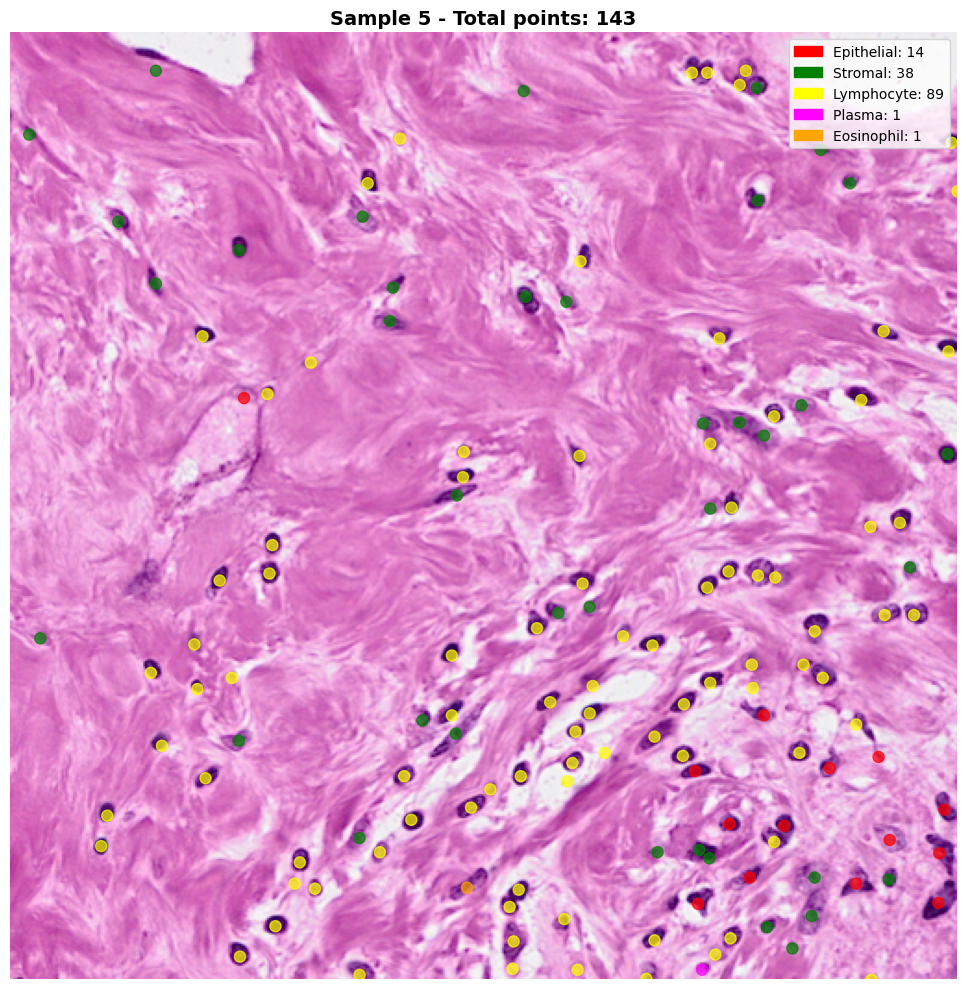


📊 Sample 5 statistics:
  Total points: 143
  Epithelial: 14
  Stromal: 38
  Lymphocyte: 89
  Plasma: 1
  Eosinophil: 1


In [10]:
# Visualization function
def visualize_p2pnet_sample(dataset, index=0):
    image_tensor, points_tensor, classes_tensor = dataset[index]
    
    image = image_tensor.numpy().transpose(1, 2, 0)
    points = points_tensor.numpy()
    classes = classes_tensor.numpy()
    
    valid_mask = (points[:, 0] >= 0) & (points[:, 1] >= 0)
    points = points[valid_mask]
    classes = classes[valid_mask]
    
    h, w = image.shape[:2]
    points_pixel = points.copy()
    points_pixel[:, 0] *= w
    points_pixel[:, 1] *= h
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(image)
    
    colors = ['red', 'green', 'yellow', 'magenta', 'dodgerblue', 'orange', 'gray']
    
    for i in range(len(points_pixel)):
        x, y = points_pixel[i]
        class_id = int(classes[i])
        color = colors[class_id] if class_id < len(colors) else 'white'
        
        circle = plt.Circle((x, y), 3, color=color, fill=True, alpha=0.7)
        ax.add_patch(circle)
    
    ax.set_title(f'Sample {index} - Total points: {len(points)}', fontsize=14, fontweight='bold')
    ax.axis('off')
    
    legend_elements = [
        patches.Patch(color=colors[i], label=f'{class_names[i]}: {sum(classes==i)}')
        for i in range(num_classes) if sum(classes==i) > 0
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n📊 Sample {index} statistics:")
    print(f"  Total points: {len(points)}")
    for i in range(num_classes):
        count = sum(classes == i)
        if count > 0:
            print(f"  {class_names[i]}: {count}")

print("🖼️ Visualizing training sample...")
visualize_p2pnet_sample(train_dataset, index=5)

In [11]:
# Training Setup
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6)

epochs = 300
save_dir = '../../model/spatialTranscriptome/detail_p2pnet/'
os.makedirs(save_dir, exist_ok=True)

train_losses = []
val_point_errors = []
val_class_accs = []
val_recalls = []
val_precisions = []
best_val_point_error = float('inf')

print(f"\n🚀 Training setup:")
print(f"  Epochs: {epochs}")
print(f"  Optimizer: AdamW (lr=1e-4, wd=1e-4)")
print(f"  Scheduler: CosineAnnealingWarmRestarts")
print(f"  Save directory: {save_dir}")


🚀 Training setup:
  Epochs: 300
  Optimizer: AdamW (lr=1e-4, wd=1e-4)
  Scheduler: CosineAnnealingWarmRestarts
  Save directory: ../../model/spatialTranscriptome/detail_p2pnet/


In [ ]:
# Training Loop
print("\n" + "="*80)
print("🚀 Starting P2PNet Training")
print("="*80)

for epoch in range(epochs):
    # TRAINING
    model.train()
    train_loss = 0
    train_point_loss = 0
    train_class_loss = 0
    train_obj_loss = 0
    train_matched = 0
    
    train_pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                     desc=f'Epoch {epoch+1}/{epochs} [Train]')
    
    for batch_idx, (images, targets) in train_pbar:
        images = images.to(device)
        targets = {k: v.to(device) for k, v in targets.items()}
        
        pred_points, pred_logits, pred_obj = model(images)
        
        if epoch == 0 and batch_idx == 0:
            print(f"\n📊 First batch info:")
            print(f"  Input shape: {images.shape}")
            print(f"  Pred points: {pred_points.shape}")
            print(f"  Pred logits: {pred_logits.shape}")
            print(f"  Pred objectness: {pred_obj.shape}")
            print(f"  GT points: {targets['points'].shape}")
            
            valid_mask = (targets['points'][0, :, 0] >= 0) & (targets['points'][0, :, 1] >= 0)
            num_valid = valid_mask.sum().item()
            print(f"  Valid GT points: {num_valid}")
            
            obj_scores = torch.sigmoid(pred_obj[0]).detach().cpu().numpy()
            print(f"  Objectness range: [{obj_scores.min():.4f}, {obj_scores.max():.4f}]")
            print(f"  Objectness > 0.5: {(obj_scores > 0.5).sum()} / {len(obj_scores)}")
        
        loss, loss_dict = criterion(pred_points, pred_logits, pred_obj, targets)
        
        if epoch == 0 and batch_idx == 0:
            print(f"\n💰 First batch loss:")
            print(f"  Total: {loss_dict['total']:.4f}")
            print(f"  Point: {loss_dict['point']:.4f} (coef=5.0)")
            print(f"  Class: {loss_dict['class']:.4f} (coef=2.0)")
            print(f"  Obj: {loss_dict['obj']:.4f} (coef=2.0)")
            print(f"  Matched: {loss_dict['num_matched']}\n")
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss_dict['total']
        train_point_loss += loss_dict['point']
        train_class_loss += loss_dict['class']
        train_obj_loss += loss_dict['obj']
        train_matched += loss_dict['num_matched']
        
        memory = f'{torch.cuda.memory_reserved() / 1E9:.2f}G'
        train_pbar.set_postfix({
            'loss': f"{loss_dict['total']:.4f}",
            'pt': f"{loss_dict['point']:.4f}",
            'cls': f"{loss_dict['class']:.4f}",
            'obj': f"{loss_dict['obj']:.4f}",
            'mem': memory
        })
    
    num_batches = len(train_loader)
    avg_train_loss = train_loss / num_batches
    avg_train_point_loss = train_point_loss / num_batches
    avg_train_class_loss = train_class_loss / num_batches
    avg_train_obj_loss = train_obj_loss / num_batches
    avg_train_matched = train_matched / num_batches
    train_losses.append(avg_train_loss)
    
    # VALIDATION
    model.eval()
    val_point_error = 0
    val_class_correct = 0
    val_total = 0
    val_recall_sum = 0
    val_precision_sum = 0
    val_samples = 0
    
    val_pbar = tqdm(enumerate(val_loader), total=len(val_loader),
                   desc=f'Epoch {epoch+1}/{epochs} [Val]')
    
    with torch.no_grad():
        for batch_idx, (images, targets) in val_pbar:
            images = images.to(device)
            targets = {k: v.to(device) for k, v in targets.items()}
            
            pred_points, pred_logits, pred_obj = model(images)
            
            batch_size = images.size(0)
            for b in range(batch_size):
                gt_points = targets['points'][b]
                gt_classes = targets['classes'][b].long()
                
                valid_mask = (gt_points[:, 0] >= 0) & (gt_points[:, 1] >= 0)
                gt_points = gt_points[valid_mask]
                gt_classes = gt_classes[valid_mask]
                
                if len(gt_points) == 0:
                    continue
                
                obj_scores = torch.sigmoid(pred_obj[b])
                obj_mask = obj_scores > 0.5
                
                if obj_mask.sum() == 0:
                    val_recall_sum += 0
                    val_precision_sum += 0
                    val_samples += 1
                    continue
                
                filtered_pred_points = pred_points[b][obj_mask]
                filtered_pred_logits = pred_logits[b][obj_mask]
                
                point_cost = torch.cdist(filtered_pred_points, gt_points, p=1)
                pred_probs = F.softmax(filtered_pred_logits, dim=-1)
                class_cost = -pred_probs[:, gt_classes]
                cost_matrix = (point_cost * 5.0 + class_cost * 2.0).detach().cpu().numpy()
                
                pred_idx, gt_idx = linear_sum_assignment(cost_matrix)
                
                matched_pred_points = filtered_pred_points[pred_idx]
                matched_gt_points = gt_points[gt_idx]
                point_error = torch.abs(matched_pred_points - matched_gt_points).mean()
                val_point_error += point_error.item()
                
                matched_pred_classes = filtered_pred_logits[pred_idx].argmax(dim=-1)
                matched_gt_classes = gt_classes[gt_idx]
                correct = (matched_pred_classes == matched_gt_classes).sum().item()
                val_class_correct += correct
                val_total += len(gt_idx)
                
                recall = len(gt_idx) / len(gt_points)
                precision = len(pred_idx) / obj_mask.sum().item()
                val_recall_sum += recall
                val_precision_sum += precision
                val_samples += 1
    
    avg_val_point_error = val_point_error / val_samples if val_samples > 0 else 0
    avg_val_class_acc = val_class_correct / val_total if val_total > 0 else 0
    avg_val_recall = val_recall_sum / val_samples if val_samples > 0 else 0
    avg_val_precision = val_precision_sum / val_samples if val_samples > 0 else 0
    avg_val_f1 = 2 * avg_val_precision * avg_val_recall / (avg_val_precision + avg_val_recall + 1e-8)
    
    val_point_errors.append(avg_val_point_error)
    val_class_accs.append(avg_val_class_acc)
    val_recalls.append(avg_val_recall)
    val_precisions.append(avg_val_precision)
    
    scheduler.step()
    
    # LOGGING
    print(f"\n{'='*80}")
    print(f"Epoch {epoch+1}/{epochs} Summary:")
    print(f"  Train Loss: {avg_train_loss:.4f} (Pt: {avg_train_point_loss:.4f}, Cls: {avg_train_class_loss:.4f}, Obj: {avg_train_obj_loss:.4f})")
    print(f"  Train Matched: {avg_train_matched:.1f} points/batch")
    print(f"  Val Point Error: {avg_val_point_error:.4f}")
    print(f"  Val Class Acc: {avg_val_class_acc:.4f}")
    print(f"  Val Recall: {avg_val_recall:.4f}")
    print(f"  Val Precision: {avg_val_precision:.4f}")
    print(f"  Val F1: {avg_val_f1:.4f}")
    print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")
    print(f"{'='*80}\n")
    
    # SAVE CHECKPOINT
    if avg_val_point_error < best_val_point_error:
        best_val_point_error = avg_val_point_error
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': avg_train_loss,
            'val_point_error': avg_val_point_error,
            'val_class_acc': avg_val_class_acc,
            'best_val_point_error': best_val_point_error
        }
        torch.save(checkpoint, os.path.join(save_dir, 'best_model.pt'))
        print(f"🎉 New best model saved! Point Error: {avg_val_point_error:.4f}\n")
    
    last_checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_loss': avg_train_loss,
        'val_point_error': avg_val_point_error,
        'val_class_acc': avg_val_class_acc
    }
    torch.save(last_checkpoint, os.path.join(save_dir, 'last_model.pt'))
    
    # PLOT PROGRESS
    if (epoch + 1) % 10 == 0:
        fig, axes = plt.subplots(2, 2, figsize=(18, 12))
        
        axes[0,0].plot(train_losses, 'b-')
        axes[0,0].set_title('Training Loss')
        axes[0,0].set_xlabel('Epoch')
        axes[0,0].grid(True)
        
        axes[0,1].plot(val_point_errors, 'r-')
        axes[0,1].set_title('Val Point Error')
        axes[0,1].set_xlabel('Epoch')
        axes[0,1].grid(True)
        
        axes[1,0].plot(val_class_accs, 'g-')
        axes[1,0].set_title('Val Class Accuracy')
        axes[1,0].set_xlabel('Epoch')
        axes[1,0].grid(True)
        
        axes[1,1].plot(val_recalls, 'c-', label='Recall')
        axes[1,1].plot(val_precisions, 'm-', label='Precision')
        axes[1,1].set_title('Val Recall & Precision')
        axes[1,1].set_xlabel('Epoch')
        axes[1,1].legend()
        axes[1,1].grid(True)
        
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, f'training_progress_epoch_{epoch+1}.png'), dpi=150)
        plt.close()

print("\n" + "="*80)
print("🎯 Training Complete!")
print(f"  Best Val Point Error: {best_val_point_error:.4f}")
print(f"  Models saved to: {save_dir}")
print("="*80)


🚀 Starting P2PNet Training


Epoch 1/300 [Train]:   0%|          | 0/12 [00:00<?, ?it/s]


📊 First batch info:
  Input shape: torch.Size([8, 3, 512, 512])
  Pred points: torch.Size([8, 4096, 2])
  Pred logits: torch.Size([8, 4096, 6])
  Pred objectness: torch.Size([8, 4096])
  GT points: torch.Size([8, 500, 2])
  Valid GT points: 362


RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

In [ ]:
# Evaluation and Visualization
def nms_points(points, scores, classes, nms_threshold=10.0):
    if len(points) == 0:
        return np.array([])
    
    points_pixel = points * 512
    sorted_indices = np.argsort(-scores)
    
    keep = []
    while len(sorted_indices) > 0:
        current_idx = sorted_indices[0]
        keep.append(current_idx)
        
        if len(sorted_indices) == 1:
            break
        
        current_point = points_pixel[current_idx]
        remaining_points = points_pixel[sorted_indices[1:]]
        distances = np.sqrt(np.sum((remaining_points - current_point) ** 2, axis=1))
        
        current_class = classes[current_idx]
        remaining_classes = classes[sorted_indices[1:]]
        same_class = (remaining_classes == current_class)
        
        keep_mask = (distances > nms_threshold) | (~same_class)
        sorted_indices = sorted_indices[1:][keep_mask]
    
    return np.array(keep)


def visualize_predictions(model, dataset, index=0, conf_threshold=0.5, obj_threshold=0.5, nms_threshold=10.0):
    model.eval()
    
    image_tensor, gt_points_tensor, gt_classes_tensor = dataset[index]
    
    valid_mask = (gt_points_tensor[:, 0] >= 0) & (gt_points_tensor[:, 1] >= 0)
    gt_points = gt_points_tensor[valid_mask].numpy()
    gt_classes = gt_classes_tensor[valid_mask].numpy()
    
    with torch.no_grad():
        image_batch = image_tensor.unsqueeze(0).to(device)
        pred_points, pred_logits, pred_obj = model(image_batch)
        pred_points = pred_points[0].cpu().numpy()
        pred_classes = pred_logits[0].argmax(dim=-1).cpu().numpy()
        pred_scores = F.softmax(pred_logits[0], dim=-1).max(dim=-1)[0].cpu().numpy()
        pred_obj_scores = torch.sigmoid(pred_obj[0]).cpu().numpy()
    
    print(f"  Total predictions: {len(pred_points)}")
    
    obj_mask = pred_obj_scores > obj_threshold
    pred_points = pred_points[obj_mask]
    pred_classes = pred_classes[obj_mask]
    pred_scores = pred_scores[obj_mask]
    pred_obj_scores = pred_obj_scores[obj_mask]
    
    print(f"  After objectness (>{obj_threshold}): {len(pred_points)}")
    
    conf_mask = pred_scores > conf_threshold
    pred_points = pred_points[conf_mask]
    pred_classes = pred_classes[conf_mask]
    pred_scores = pred_scores[conf_mask]
    
    print(f"  After confidence (>{conf_threshold}): {len(pred_points)}")
    
    if len(pred_points) > 0:
        keep_indices = nms_points(pred_points, pred_scores, pred_classes, nms_threshold=nms_threshold)
        pred_points = pred_points[keep_indices]
        pred_classes = pred_classes[keep_indices]
        pred_scores = pred_scores[keep_indices]
        
        print(f"  After NMS ({nms_threshold}px): {len(pred_points)}")
    
    image = image_tensor.numpy().transpose(1, 2, 0)
    h, w = image.shape[:2]
    
    gt_points_pixel = gt_points.copy()
    gt_points_pixel[:, 0] *= w
    gt_points_pixel[:, 1] *= h
    
    pred_points_pixel = pred_points.copy()
    pred_points_pixel[:, 0] *= w
    pred_points_pixel[:, 1] *= h
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    colors = ['red', 'green', 'yellow', 'magenta', 'dodgerblue', 'orange']
    
    axes[0].imshow(image)
    for i in range(len(gt_points_pixel)):
        x, y = gt_points_pixel[i]
        class_id = int(gt_classes[i])
        color = colors[class_id] if class_id < len(colors) else 'white'
        circle = plt.Circle((x, y), 4, color=color, fill=True, alpha=0.8)
        axes[0].add_patch(circle)
    axes[0].set_title(f'Ground Truth ({len(gt_points_pixel)} points)', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(image)
    for i in range(len(pred_points_pixel)):
        x, y = pred_points_pixel[i]
        class_id = int(pred_classes[i])
        color = colors[class_id] if class_id < len(colors) else 'white'
        circle = plt.Circle((x, y), 4, color=color, fill=True, alpha=0.8)
        axes[1].add_patch(circle)
    
    axes[1].set_title(f'Predictions ({len(pred_points_pixel)} points)', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    legend_elements = [
        patches.Patch(color=colors[i], label=class_names[i])
        for i in range(num_classes)
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=num_classes,
              bbox_to_anchor=(0.5, -0.05), fontsize=12)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)
    plt.show()
    
    print(f"\n📊 Sample {index} statistics:")
    print(f"  Ground Truth: {len(gt_points_pixel)} points")
    print(f"  Predictions: {len(pred_points_pixel)} points")


# Load best model
checkpoint_path = os.path.join(save_dir, 'best_model.pt')
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"✅ Best model loaded (Epoch {checkpoint['epoch']+1})")
    print(f"  Val Point Error: {checkpoint.get('val_point_error', 'N/A'):.4f}")

print("\n🖼️ Visualizing predictions...")
sample_idx = random.randint(0, len(val_dataset)-1)
visualize_predictions(model, val_dataset, index=sample_idx, conf_threshold=0.5, obj_threshold=0.5, nms_threshold=10.0)